## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

%matplotlib inline

## Data

In [2]:
# 4 clusters of data based on distribution
x1 = np.random.multivariate_normal([-5,5.5], [[1.0, 0.0], [0.0, 1.0]], 75).T
x2 = np.random.multivariate_normal([-4,-2], [[5.0, 0.0], [0.0, 3.0]], 75).T
x3 = np.random.multivariate_normal([5,5], [[3.0, 0.0], [0.0, 2.0]], 75).T
x4 = np.random.multivariate_normal([2,11], [[1.0, 0.0], [0.0, 1.0]], 75).T
x5 = np.random.multivariate_normal([3,-3], [[2.0, 0.0], [0.0, 2.0]], 75).T

points = np.hstack((x1, x2, x3, x4, x5))

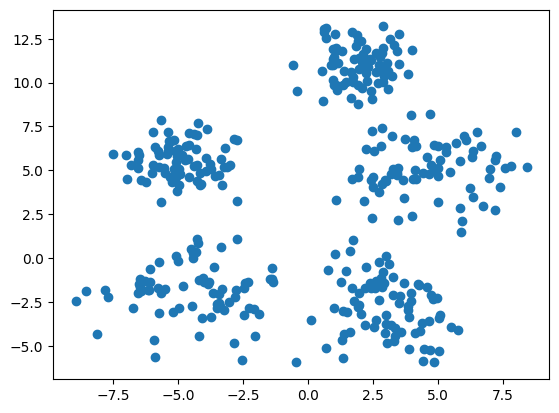

In [3]:
plt.scatter(points[0], points[1])

## K-Means implementation

### Steps:
- Choose k random points as the initial centroids
- Assign each point to its closest centroid
- Compute the new centroid for each cluster
- Repeat until # iterations done, or can also stop when no updates.

In [4]:
# Returns the mean (centroid) of a given set of points.
def calc_centroid(points):  
  return np.mean(points, axis=0)

In [5]:
# Gets L2 distance of two vectors.
def get_dist(v, w):
  return np.linalg.norm(v-w)

In [6]:
# Given a point, return the closest centroid.
def get_closest_centroid(point, centroids):
  min_distance = float('inf')
  c = None

  for c_i, centroid in enumerate(centroids):
    dist = get_dist(centroid, point)
    if dist < min_distance:
      min_distance = dist
      c = c_i

  return c

In [8]:
# Returns the classes for points based on k-means algorithm.
# points:     The set of points
# k:          # of clusters
# iterations: # of iterations to run
def k_means(points, k, iterations):  
  N = len(points)

  # Cluster each point is assigned to. Initially all set to 0.
  point_clusters = [0] * N

  # Choose k random points as the initial centroids
  initial_centroids = random.sample(range(0, N), k)
  # Stores the centroids for each of the cluster ids from 0 to k-1
  id_to_centroid = points[initial_centroids]

  for i in range(iterations):
    # Keep track of all points that are in each cluster
    cluster_points = [[] for _ in range(k)]

    # Assign each point to its closest centroid
    for j in range(N):
      point = points[j]
      closest_cluster_id = get_closest_centroid(point, id_to_centroid)
      point_clusters[j] = closest_cluster_id
      cluster_points[closest_cluster_id].append(j)

    # Compute the new centroid for each cluster of points
    for c_id, points_in_centroid in enumerate(cluster_points):
      new_centroid = calc_centroid(points[points_in_centroid])
      id_to_centroid[c_id] = new_centroid 

  return point_clusters

## Visualize the results

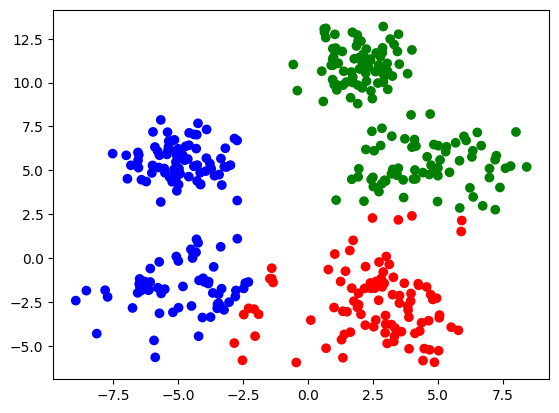

In [10]:
k = 3
clusters1 = k_means(points.T, k, 100)

colormap = np.array(['r', 'g', 'b'])
plt.scatter(points[0], points[1], c=colormap[clusters1])

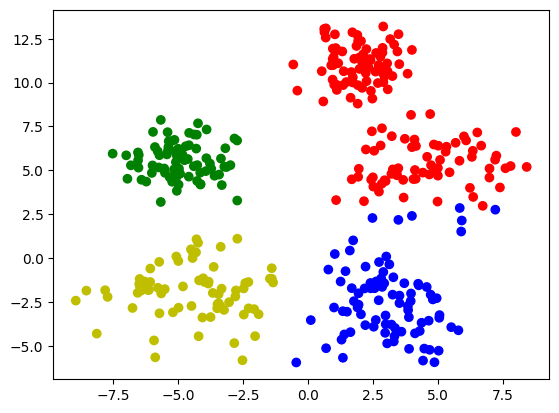

In [15]:
k = 4
clusters2 = k_means(points.T, k, 100)

colormap = np.array(['r', 'g', 'b', 'y'])
plt.scatter(points[0], points[1], c=colormap[clusters2])

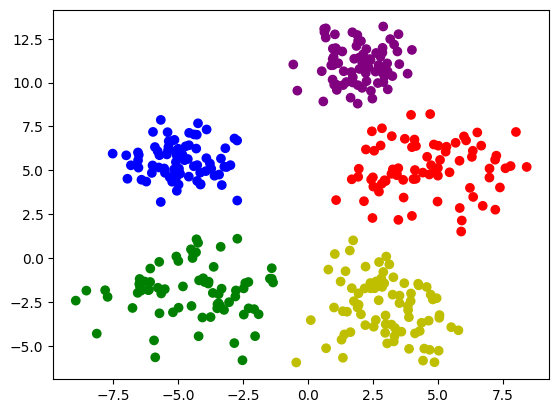

In [16]:
k = 5
clusters2 = k_means(points.T, k, 100)

colormap = np.array(['r', 'g', 'b', 'y', 'purple'])
plt.scatter(points[0], points[1], c=colormap[clusters2])